# Pneumonia Classification from Chest X-Rays
## Deep Learning Final Project

### Name and ID:
Student 1: Shalev Bell 329702450
<br>
Student 2: Amit Mosseri 206446791

**Course:** Deep Learning  

---

## Project Overview

This project implements three different approaches to classify chest X-ray images into three categories:
- **Class 0**: Normal (Healthy)
- **Class 1**: Viral Pneumonia
- **Class 2**: Bacterial Pneumonia

### Three Approaches:
1. **Task A**: Custom CNN architecture built from scratch
2. **Task B**: Transfer learning using EfficientNetB0 (frozen + fine-tuned)
3. **Task C**: Vision Transformer approach using RNN to process image patches

### Dataset
Using the Kaggle Chest X-Ray Pneumonia dataset with ~5,800 images total.

---

UPDATE_CHECK_MARKER_2026_02_23_PYTORCH_UPGRADE

## 1. Setup & Configuration

In [ ]:
!pip install -q timm kagglehub gdown pillow scikit-learn tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import models
import timm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
import os
import random
from tqdm import tqdm
import time
from pathlib import Path
import shutil
from torch.cuda.amp import GradScaler, autocast

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
SEED = 18
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

WEIGHTS_DIR = '/content/drive/MyDrive/dl_project_weights'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
print(f"Weights will be saved to: {WEIGHTS_DIR}")

Mounted at /content/drive
Weights will be saved to: /content/drive/MyDrive/dl_project_weights


## 2. Dataset Preparation

We'll download the Kaggle Chest X-Ray Pneumonia dataset and prepare it for 3-class classification:
- Parse filenames to distinguish Viral vs Bacterial pneumonia
- Merge train + validation sets and re-split (original val set has only 16 images)
- Create proper train/val/test splits

In [ ]:
import kagglehub

print("Downloading Chest X-Ray Pneumonia dataset...")
dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(f"Dataset downloaded to: {dataset_path}")

data_root = Path(dataset_path)
if (data_root / 'chest_xray').exists():
    data_root = data_root / 'chest_xray'
print(f"Data root: {data_root}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to: /kaggle/input/chest-xray-pneumonia
Data root: /kaggle/input/chest-xray-pneumonia/chest_xray


In [ ]:
class_names = ['Normal', 'Viral Pneumonia', 'Bacterial Pneumonia']
NUM_CLASSES = len(class_names)


def parse_label(filename):
    """
    Parse filename to determine class:
    - 0: Normal
    - 1: Viral Pneumonia
    - 2: Bacterial Pneumonia
    """
    filename_lower = filename.lower()

    if 'bacteria' in filename_lower:
        return 2
    elif 'virus' in filename_lower:
        return 1
    else:
        return 0


def collect_dataset(split_dir):
    """
    Collect all images from NORMAL and PNEUMONIA folders
    """
    images = []
    labels = []

    normal_dir = split_dir / 'NORMAL'
    if normal_dir.exists():
        for img_path in normal_dir.glob('*.jpeg'):
            images.append(str(img_path))
            labels.append(0)  # Normal

    pneumonia_dir = split_dir / 'PNEUMONIA'
    if pneumonia_dir.exists():
        for img_path in pneumonia_dir.glob('*.jpeg'):
            images.append(str(img_path))
            labels.append(parse_label(img_path.name))

    return images, labels


print("Collecting training and validation data...")
train_images, train_labels = collect_dataset(data_root / 'train')
val_images, val_labels = collect_dataset(data_root / 'val')

merged_images = train_images + val_images
merged_labels = train_labels + val_labels

print(f"Original train: {len(train_images)}, val: {len(val_images)}")
print(f"Merged: {len(merged_images)}")

test_images, test_labels = collect_dataset(data_root / 'test')
print(f"Test: {len(test_images)}")

print()
print("Class distribution in merged train+val:")
unique, counts = np.unique(merged_labels, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({class_names[cls]}): {count}")

print()
print("Class distribution in test:")
unique, counts = np.unique(test_labels, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({class_names[cls]}): {count}")

Original train: 5216, val: 16
Merged: 5232
Test: 624

Class distribution in merged train+val:
  Class 0 (Normal): 1349
  Class 1 (Viral Pneumonia): 1345
  Class 2 (Bacterial Pneumonia): 2538

Class distribution in test:
  Class 0 (Normal): 234
  Class 1 (Viral Pneumonia): 148
  Class 2 (Bacterial Pneumonia): 242


In [ ]:
class ChestXRayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.95, 1.05), fill=0),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))
    ], p=0.15),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.5, 2.0), value='random'),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print("Transforms defined.")

Transforms defined.


In [ ]:
# Train/val split (80/20)
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_lbls, val_lbls = train_test_split(
    merged_images, merged_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=merged_labels
)

print(f"Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_images)}")

train_dataset = ChestXRayDataset(train_imgs, train_lbls, transform=train_transform)
val_dataset = ChestXRayDataset(val_imgs, val_lbls, transform=val_transform)
test_dataset = ChestXRayDataset(test_images, test_labels, transform=val_transform)

BATCH_SIZE = 32
NUM_WORKERS = 2

# Class-balanced sampling to reduce bias toward the majority class.
train_class_counts = np.bincount(train_lbls, minlength=NUM_CLASSES)
inv_freq = 1.0 / np.maximum(train_class_counts, 1)
sample_weights = torch.DoubleTensor([inv_freq[label] for label in train_lbls])
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Smoothed class weights for loss function.
raw_class_weights = len(train_lbls) / (NUM_CLASSES * np.maximum(train_class_counts, 1))
class_weights = np.sqrt(raw_class_weights)
class_weights = class_weights / class_weights.mean()
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float32)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0
)

print()
print(f"DataLoaders created with batch size {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
print()
print("Training class counts:")
for idx, count in enumerate(train_class_counts):
    print(f"  {class_names[idx]}: {count}")
print(f"Class weights (loss): {class_weights.round(3).tolist()}")

Train: 4185, Val: 1047, Test: 624

DataLoaders created with batch size 32
Train batches: 131, Val batches: 33, Test batches: 20

Training class counts:
  Normal: 1079
  Viral Pneumonia: 1076
  Bacterial Pneumonia: 2030
Class weights (loss): [1.099, 1.1, 0.801]


## 2.5. Execution Mode: Train from Scratch OR Use Pre-trained Weights

Set `USE_PRETRAINED = False`
- Runs all training (Tasks A, B, C)
- Saves weights to Google Drive
---
Set `USE_PRETRAINED = True`
- Downloads pre-trained weights via gdown
- Skips all training sections
- Only runs evaluation


In [ ]:
USE_PRETRAINED = True

WEIGHT_FILE_IDS = {
    'task_a': '1M3o-AQgMuw2ro_KvucNuiTpl5MkjK_Vi',      # task_a_custom_cnn.pth
    'task_b1': '1UQFmT9hELMkmL1a5nMB1y0wWj0EH1n2X',    # task_b1_efficientnet_frozen.pth
    'task_b2': '1LdgYn9h2g3b-1N3mByVYb6u9IU69NHgP',    # task_b2_efficientnet_finetuned.pth
    'task_c': '15Jd4cbGY2siRdoydp6oeLIWAw_i0lIcG'       # task_c_vit_rnn.pth
}

WEIGHT_PATHS = {
    'task_a': os.path.join(WEIGHTS_DIR, 'task_a_custom_cnn.pth'),
    'task_b1': os.path.join(WEIGHTS_DIR, 'task_b1_efficientnet_frozen.pth'),
    'task_b2': os.path.join(WEIGHTS_DIR, 'task_b2_efficientnet_finetuned.pth'),
    'task_c': os.path.join(WEIGHTS_DIR, 'task_c_vit_rnn.pth')
}

print("EXECUTION MODE CONFIGURATION")
print("="*70)
print(f"Mode: {'USE PRE-TRAINED WEIGHTS' if USE_PRETRAINED else 'TRAIN FROM SCRATCH'}")
print(f"Training will be: {'SKIPPED' if USE_PRETRAINED else 'EXECUTED'}")
print(f"Weights directory: {WEIGHTS_DIR}")

EXECUTION MODE CONFIGURATION
Mode: TRAIN FROM SCRATCH
Training will be: EXECUTED
Weights directory: /content/drive/MyDrive/dl_project_weights


In [ ]:
if USE_PRETRAINED:
    print("DOWNLOADING PRE-TRAINED WEIGHTS")
    print("="*70 + "\n")

    if any('YOUR_' in file_id for file_id in WEIGHT_FILE_IDS.values()):
        print("WARNING: File IDs not set!")
        print("Please update WEIGHT_FILE_IDS with your actual Google Drive File IDs")
        print("See WEIGHT_SHARING_GUIDE.md for instructions")
        print("\nCurrent File IDs:")
        for key, file_id in WEIGHT_FILE_IDS.items():
            print(f"  {key}: {file_id}")
        raise ValueError("Please set actual File IDs before using pre-trained mode")

    import gdown

    download_success = {}

    for task_name, file_id in WEIGHT_FILE_IDS.items():
        weight_path = WEIGHT_PATHS[task_name]
        weight_filename = os.path.basename(weight_path)

        print(f"\n[{task_name.upper()}] Downloading {weight_filename}...")
        print(f"File ID: {file_id}")

        try:
            output_path = weight_path
            url = f'https://drive.google.com/uc?id={file_id}'
            gdown.download(url, output_path, quiet=False)

            if os.path.exists(output_path):
                file_size = os.path.getsize(output_path) / (1024 * 1024)  # MB
                print(f"Successfully downloaded: {weight_filename} ({file_size:.2f} MB)")
                download_success[task_name] = True
            else:
                print(f"Failed: File not found after download")
                download_success[task_name] = False

        except Exception as e:
            print(f"Error downloading {weight_filename}: {str(e)}")
            download_success[task_name] = False

    print("DOWNLOAD SUMMARY")
    print("="*70)

    all_success = all(download_success.values())

    for task_name, success in download_success.items():
        status = "SUCCESS" if success else "FAILED"
        print(f"  {task_name}: {status}")

    print("="*70)

    if not all_success:
        print("\nSome downloads failed! Please check:")
        print("1. File IDs are correct (no typos)")
        print("2. Google Drive files have 'Anyone with link' permission")
        print("3. File IDs are from the shareable link's format:")
        print("   https://drive.google.com/file/d/FILE_ID_HERE/view")
        raise RuntimeError("Weight download failed. Cannot proceed with evaluation.")

    print("\nAll weights downloaded successfully!")
    print("Training sections will be SKIPPED")
    print("Proceeding directly to model evaluation...\n")

else:
    print("TRAINING MODE")
    print("="*70)
    print("Models will be trained from scratch")
    print("Weights will be saved to Google Drive after each task")

TRAINING MODE
Models will be trained from scratch
Weights will be saved to Google Drive after each task


## 3. Task A - Custom CNN Architecture

Building a convolutional neural network from scratch for 3-class classification.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CustomCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 5
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model_a = CustomCNN(num_classes=3).to(device)

total_params = sum(p.numel() for p in model_a.parameters())
trainable_params = sum(p.numel() for p in model_a.parameters() if p.requires_grad)

print(f"Custom CNN created")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Custom CNN created
Total parameters: 4,848,291
Trainable parameters: 4,848,291


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device, scaler=None, max_grad_norm=None, use_amp=False):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            if max_grad_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        avg_loss = running_loss / (batch_idx + 1)
        avg_acc = 100.0 * correct / total
        pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'acc': f'{avg_acc:.2f}'})

    epoch_loss = running_loss / max(len(loader), 1)
    epoch_acc = 100.0 * correct / max(total, 1)
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device, use_amp=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(tqdm(loader, desc='Validation', leave=False)):
            images, labels = images.to(device), labels.to(device)
            with autocast(enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / max(len(loader), 1)
    epoch_acc = 100.0 * correct / max(total, 1)
    return epoch_loss, epoch_acc

In [ ]:
if USE_PRETRAINED:
    print("SKIPPING Task A Training (using pre-trained weights)")
    print("="*50)
    print()
    print(f"Pre-trained weights will be loaded from: {WEIGHT_PATHS['task_a']}")
    training_time_a = 0
    best_val_acc = 0
    history_a = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

else:
    print("Training Task A: Custom CNN")
    print("="*50)
    print()

    use_amp = device.type == 'cuda'
    scaler = GradScaler(enabled=use_amp)

    criterion_a = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR.to(device), label_smoothing=0.05)
    optimizer_a = optim.AdamW(model_a.parameters(), lr=3e-4, weight_decay=1e-4)

    NUM_EPOCHS_A = 32
    scheduler_a = optim.lr_scheduler.CosineAnnealingLR(optimizer_a, T_max=NUM_EPOCHS_A, eta_min=1e-6)

    best_val_acc = 0.0
    best_epoch = 0
    early_stop_patience = 8
    epochs_without_improvement = 0
    history_a = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    start_time = time.time()

    for epoch in range(NUM_EPOCHS_A):
        print()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_A}")

        train_loss, train_acc = train_epoch(
            model_a, train_loader, criterion_a, optimizer_a, device,
            scaler=scaler, max_grad_norm=1.0, use_amp=use_amp
        )
        val_loss, val_acc = validate(model_a, val_loader, criterion_a, device, use_amp=use_amp)

        scheduler_a.step()
        current_lr = optimizer_a.param_groups[0]['lr']

        history_a['train_loss'].append(train_loss)
        history_a['train_acc'].append(train_acc)
        history_a['val_loss'].append(val_loss)
        history_a['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, LR: {current_lr:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            torch.save(model_a.state_dict(), os.path.join(WEIGHTS_DIR, 'task_a_custom_cnn.pth'))
            print(f"✓ Best model saved (Val Acc: {val_acc:.2f}%)")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stop_patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs).")
            break

    training_time_a = time.time() - start_time
    print()
    print(f"Task A training completed in {training_time_a/60:.2f} minutes")
    print(f"Best validation accuracy: {best_val_acc:.2f}% (epoch {best_epoch})")

/tmp/ipython-input-2236778879.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


Training Task A: Custom CNN


Epoch 1/32


Training:   0%|          | 0/131 [00:00<?, ?it/s]/tmp/ipython-input-1937787074.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Validation:   0%|          | 0/33 [00:00<?, ?it/s]/tmp/ipython-input-1937787074.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Train Loss: 0.8215, Train Acc: 58.23%
Val Loss: 1.1484, Val Acc: 54.44%, LR: 0.000299
✓ Best model saved (Val Acc: 54.44%)

Epoch 2/32


Train Loss: 0.7030, Train Acc: 65.73%
Val Loss: 0.8679, Val Acc: 67.62%, LR: 0.000297
✓ Best model saved (Val Acc: 67.62%)

Epoch 3/32


...

Train Loss: 0.5560, Train Acc: 77.97%
Val Loss: 0.6437, Val Acc: 77.75%, LR: 0.000165

Epoch 16/32


Train Loss: 0.5463, Train Acc: 78.18%
Val Loss: 0.6090, Val Acc: 78.32%, LR: 0.000150

Epoch 17/32


Train Loss: 0.5476, Train Acc: 77.56%
Val Loss: 0.6461, Val Acc: 76.89%, LR: 0.000136

Epoch 18/32


Train Loss: 0.5529, Train Acc: 77.68%
Val Loss: 0.6237, Val Acc: 76.79%, LR: 0.000121

Epoch 19/32


Train Loss: 0.5398, Train Acc: 78.06%
Val Loss: 0.6275, Val Acc: 77.94%, LR: 0.000107
Early stopping at epoch 19 (no improvement for 8 epochs).

Task A training completed in 39.22 minutes
Best validation accuracy: 78.32% (epoch 11)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

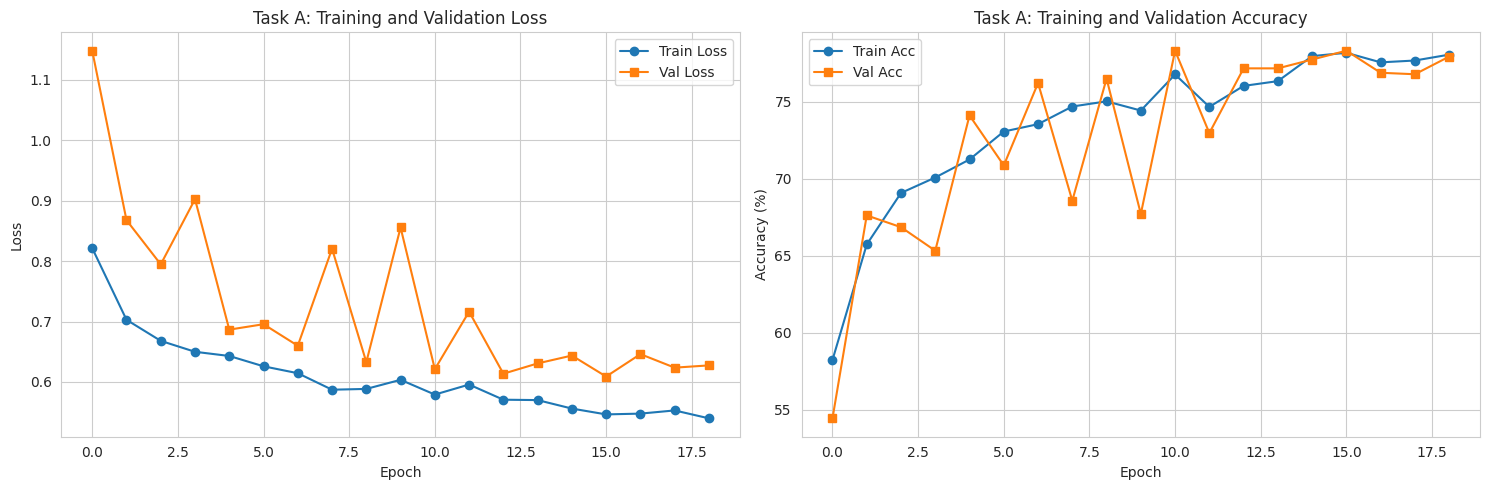

In [ ]:
if USE_PRETRAINED:
    print("Skipping training curve plot (no training was performed)")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history_a['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history_a['val_loss'], label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Task A: Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history_a['train_acc'], label='Train Acc', marker='o')
    ax2.plot(history_a['val_acc'], label='Val Acc', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Task A: Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## 4. Task B - Transfer Learning with EfficientNetB0

### Part B1: Frozen Backbone
Training only the classification head while keeping EfficientNetB0 backbone frozen.

In [ ]:
def build_efficientnet_b0(num_classes=3, pretrained=True):
    model = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=num_classes)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(0.40),
        nn.Linear(in_features, 256),
        nn.SiLU(inplace=True),
        nn.Dropout(0.25),
        nn.Linear(256, num_classes)
    )
    return model


model_b1 = build_efficientnet_b0(num_classes=NUM_CLASSES, pretrained=True)

for name, param in model_b1.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

model_b1 = model_b1.to(device)

total_params = sum(p.numel() for p in model_b1.parameters())
trainable_params = sum(p.numel() for p in model_b1.parameters() if p.requires_grad)

print("EfficientNetB0 (Frozen) created")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNetB0 (Frozen) created
Total parameters: 4,338,815
Trainable parameters: 331,267


In [ ]:
if USE_PRETRAINED:
    print("SKIPPING Task B1 Training (using pre-trained weights)")
    print("="*50)
    print()
    print(f"Pre-trained weights will be loaded from: {WEIGHT_PATHS['task_b1']}")
    training_time_b1 = 0
    best_val_acc_b1 = 0
    history_b1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

else:
    print("Training Task B1: EfficientNetB0 (Frozen Backbone)")
    print("="*50)
    print()

    use_amp = device.type == 'cuda'
    scaler = GradScaler(enabled=use_amp)

    criterion_b1 = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR.to(device), label_smoothing=0.05)
    optimizer_b1 = optim.AdamW(
        filter(lambda p: p.requires_grad, model_b1.parameters()),
        lr=1e-3,
        weight_decay=1e-4
    )

    NUM_EPOCHS_B1 = 20
    scheduler_b1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_b1, T_max=NUM_EPOCHS_B1, eta_min=1e-6)

    best_val_acc_b1 = 0.0
    best_epoch_b1 = 0
    early_stop_patience_b1 = 6
    epochs_without_improvement_b1 = 0
    history_b1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    start_time = time.time()

    for epoch in range(NUM_EPOCHS_B1):
        print()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_B1}")

        train_loss, train_acc = train_epoch(
            model_b1, train_loader, criterion_b1, optimizer_b1, device,
            scaler=scaler, max_grad_norm=1.0, use_amp=use_amp
        )
        val_loss, val_acc = validate(model_b1, val_loader, criterion_b1, device, use_amp=use_amp)

        scheduler_b1.step()
        current_lr = optimizer_b1.param_groups[0]['lr']

        history_b1['train_loss'].append(train_loss)
        history_b1['train_acc'].append(train_acc)
        history_b1['val_loss'].append(val_loss)
        history_b1['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, LR: {current_lr:.6f}")

        if val_acc > best_val_acc_b1:
            best_val_acc_b1 = val_acc
            best_epoch_b1 = epoch + 1
            epochs_without_improvement_b1 = 0
            torch.save(model_b1.state_dict(), os.path.join(WEIGHTS_DIR, 'task_b1_efficientnet_frozen.pth'))
            print(f"✓ Best model saved (Val Acc: {val_acc:.2f}%)")
        else:
            epochs_without_improvement_b1 += 1

        if epochs_without_improvement_b1 >= early_stop_patience_b1:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience_b1} epochs).")
            break

    training_time_b1 = time.time() - start_time
    print()
    print(f"Task B1 training completed in {training_time_b1/60:.2f} minutes")
    print(f"Best validation accuracy: {best_val_acc_b1:.2f}% (epoch {best_epoch_b1})")

/tmp/ipython-input-2413011792.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


Training Task B1: EfficientNetB0 (Frozen Backbone)


Epoch 1/20


Training:   0%|          | 0/131 [00:00<?, ?it/s]/tmp/ipython-input-1937787074.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Validation:   0%|          | 0/33 [00:00<?, ?it/s]/tmp/ipython-input-1937787074.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Train Loss: 0.6981, Train Acc: 70.39%
Val Loss: 0.7063, Val Acc: 69.72%, LR: 0.000994
✓ Best model saved (Val Acc: 69.72%)

Epoch 2/20


Train Loss: 0.6428, Train Acc: 73.12%
Val Loss: 0.7404, Val Acc: 70.68%, LR: 0.000976
✓ Best model saved (Val Acc: 70.68%)

Epoch 3/20


...

Train Loss: 0.6119, Train Acc: 74.67%
Val Loss: 0.7338, Val Acc: 68.96%, LR: 0.000854

Epoch 6/20


Train Loss: 0.6189, Train Acc: 74.65%
Val Loss: 0.7499, Val Acc: 67.24%, LR: 0.000794

Epoch 7/20


Train Loss: 0.5818, Train Acc: 76.82%
Val Loss: 0.7755, Val Acc: 66.95%, LR: 0.000727

Epoch 8/20


Train Loss: 0.6081, Train Acc: 75.32%
Val Loss: 0.7467, Val Acc: 70.01%, LR: 0.000655

Epoch 9/20


Train Loss: 0.5951, Train Acc: 76.20%
Val Loss: 0.7302, Val Acc: 68.58%, LR: 0.000579
Early stopping at epoch 9 (no improvement for 6 epochs).

Task B1 training completed in 18.24 minutes
Best validation accuracy: 71.44% (epoch 3)


### Part B2: Fine-tuning
Unfreezing the last blocks and fine-tuning with a lower learning rate.

In [ ]:
if USE_PRETRAINED:
    print("SKIPPING Task B2 Training (using pre-trained weights)")
    print("="*50)
    print()
    print(f"Pre-trained weights will be loaded from: {WEIGHT_PATHS['task_b2']}")
    model_b2 = build_efficientnet_b0(num_classes=NUM_CLASSES, pretrained=False).to(device)
    training_time_b2 = 0
    best_val_acc_b2 = 0
    history_b2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

else:
    print("Task B2: Fine-tuning EfficientNetB0")
    print("="*50)
    print()

    model_b2 = build_efficientnet_b0(num_classes=NUM_CLASSES, pretrained=False)
    model_b2.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, 'task_b1_efficientnet_frozen.pth')))
    model_b2 = model_b2.to(device)

    # Unfreeze deeper blocks + head for richer domain adaptation.
    for name, param in model_b2.named_parameters():
        if (
            'blocks.5' in name or
            'blocks.6' in name or
            'blocks.7' in name or
            'conv_head' in name or
            'bn2' in name or
            'classifier' in name
        ):
            param.requires_grad = True
        else:
            param.requires_grad = False

    trainable_params = sum(p.numel() for p in model_b2.parameters() if p.requires_grad)
    print(f"Trainable parameters after unfreezing: {trainable_params:,}")

    backbone_params = []
    head_params = []
    for name, param in model_b2.named_parameters():
        if not param.requires_grad:
            continue
        if 'classifier' in name:
            head_params.append(param)
        else:
            backbone_params.append(param)

    optimizer_b2 = optim.AdamW([
        {'params': backbone_params, 'lr': 5e-5, 'weight_decay': 1e-4},
        {'params': head_params, 'lr': 2e-4, 'weight_decay': 1e-4}
    ])

    criterion_b2 = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR.to(device), label_smoothing=0.05)

    NUM_EPOCHS_B2 = 18
    scheduler_b2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_b2, T_max=NUM_EPOCHS_B2, eta_min=1e-6)
    use_amp = device.type == 'cuda'
    scaler = GradScaler(enabled=use_amp)

    best_val_acc_b2 = 0.0
    best_epoch_b2 = 0
    early_stop_patience_b2 = 6
    epochs_without_improvement_b2 = 0
    history_b2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    start_time = time.time()

    for epoch in range(NUM_EPOCHS_B2):
        print()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_B2}")

        train_loss, train_acc = train_epoch(
            model_b2, train_loader, criterion_b2, optimizer_b2, device,
            scaler=scaler, max_grad_norm=1.0, use_amp=use_amp
        )
        val_loss, val_acc = validate(model_b2, val_loader, criterion_b2, device, use_amp=use_amp)

        scheduler_b2.step()
        current_lr_backbone = optimizer_b2.param_groups[0]['lr']
        current_lr_head = optimizer_b2.param_groups[1]['lr']

        history_b2['train_loss'].append(train_loss)
        history_b2['train_acc'].append(train_acc)
        history_b2['val_loss'].append(val_loss)
        history_b2['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, "
            f"LR(backbone/head): {current_lr_backbone:.6f}/{current_lr_head:.6f}"
        )

        if val_acc > best_val_acc_b2:
            best_val_acc_b2 = val_acc
            best_epoch_b2 = epoch + 1
            epochs_without_improvement_b2 = 0
            torch.save(model_b2.state_dict(), os.path.join(WEIGHTS_DIR, 'task_b2_efficientnet_finetuned.pth'))
            print(f"✓ Best model saved (Val Acc: {val_acc:.2f}%)")
        else:
            epochs_without_improvement_b2 += 1

        if epochs_without_improvement_b2 >= early_stop_patience_b2:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience_b2} epochs).")
            break

    training_time_b2 = time.time() - start_time
    print()
    print(f"Task B2 training completed in {training_time_b2/60:.2f} minutes")
    print(f"Best validation accuracy: {best_val_acc_b2:.2f}% (epoch {best_epoch_b2})")

Task B2: Fine-tuning EfficientNetB0



/tmp/ipython-input-606443746.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


Trainable parameters after unfreezing: 3,494,335

Epoch 1/18


Training:   0%|          | 0/131 [00:00<?, ?it/s]/tmp/ipython-input-1937787074.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Validation:   0%|          | 0/33 [00:00<?, ?it/s]/tmp/ipython-input-1937787074.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Train Loss: 0.5794, Train Acc: 77.49%
Val Loss: 0.6547, Val Acc: 74.98%, LR(backbone/head): 0.000050/0.000198
✓ Best model saved (Val Acc: 74.98%)

Epoch 2/18


...

Train Loss: 0.3986, Train Acc: 88.29%
Val Loss: 0.6299, Val Acc: 78.51%, LR(backbone/head): 0.000007/0.000024
✓ Best model saved (Val Acc: 78.51%)

Epoch 15/18


Train Loss: 0.4085, Train Acc: 87.60%
Val Loss: 0.6176, Val Acc: 77.84%, LR(backbone/head): 0.000004/0.000014

Epoch 16/18


Train Loss: 0.3996, Train Acc: 88.36%
Val Loss: 0.6364, Val Acc: 77.65%, LR(backbone/head): 0.000002/0.000007

Epoch 17/18


Train Loss: 0.3916, Train Acc: 88.63%
Val Loss: 0.6234, Val Acc: 78.22%, LR(backbone/head): 0.000001/0.000003

Epoch 18/18


Train Loss: 0.4075, Train Acc: 87.24%
Val Loss: 0.6265, Val Acc: 78.22%, LR(backbone/head): 0.000001/0.000001

Task B2 training completed in 37.09 minutes
Best validation accuracy: 78.51% (epoch 14)


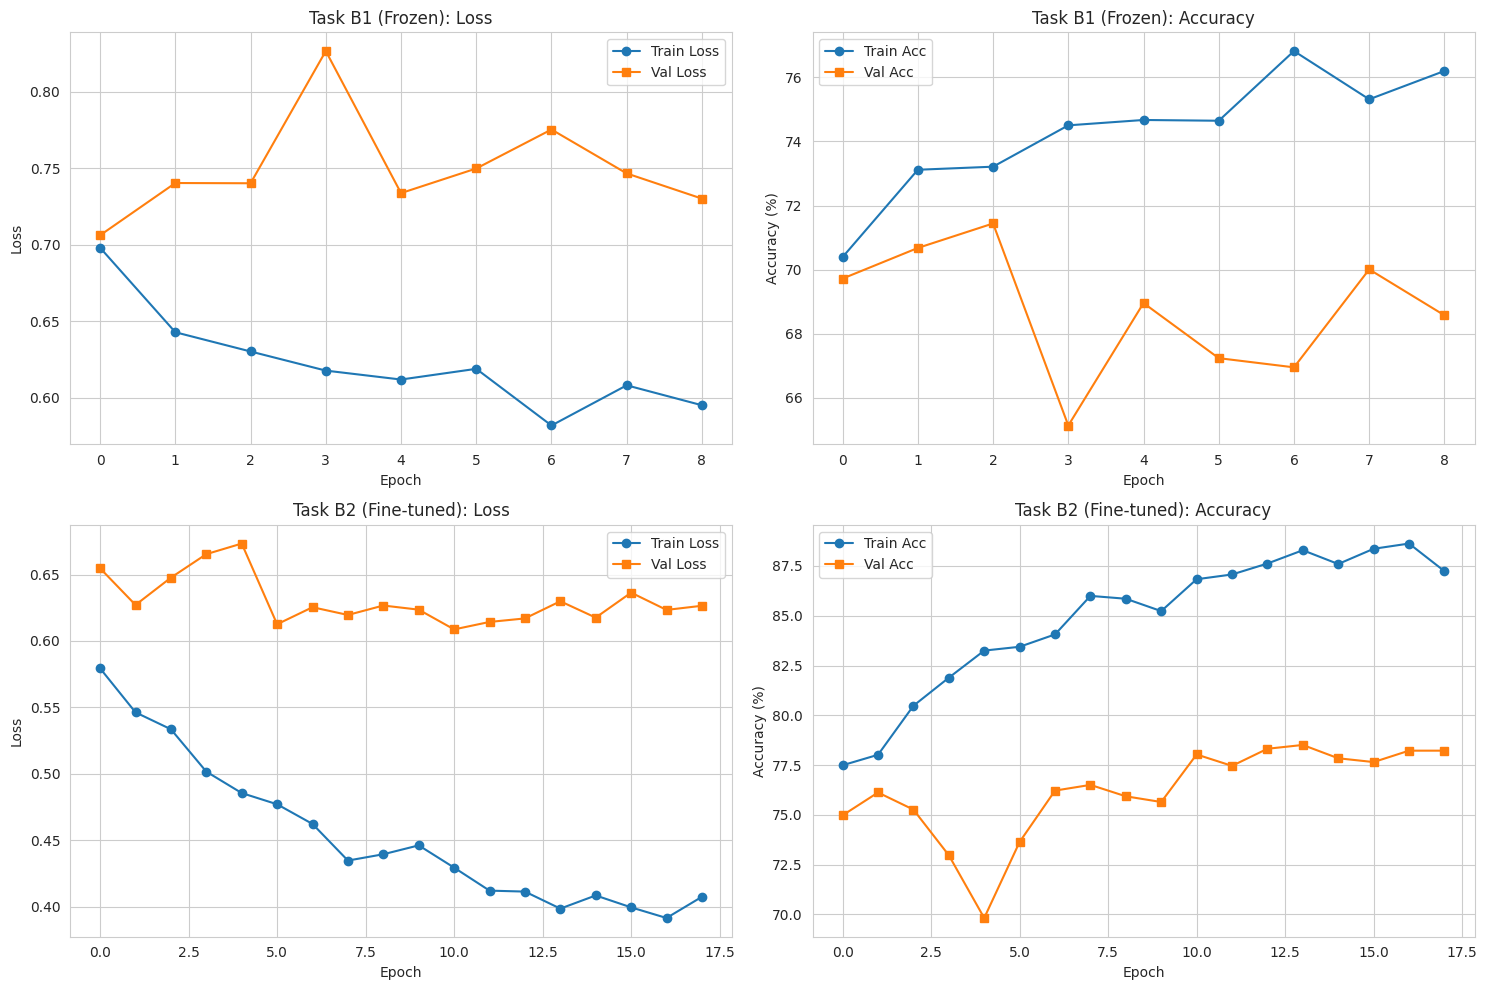

In [ ]:
if USE_PRETRAINED:
    print("Skipping training curve plot (no training was performed)")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(history_b1['train_loss'], label='Train Loss', marker='o')
    axes[0, 0].plot(history_b1['val_loss'], label='Val Loss', marker='s')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Task B1 (Frozen): Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(history_b1['train_acc'], label='Train Acc', marker='o')
    axes[0, 1].plot(history_b1['val_acc'], label='Val Acc', marker='s')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Task B1 (Frozen): Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(history_b2['train_loss'], label='Train Loss', marker='o')
    axes[1, 0].plot(history_b2['val_loss'], label='Val Loss', marker='s')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].set_title('Task B2 (Fine-tuned): Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(history_b2['train_acc'], label='Train Acc', marker='o')
    axes[1, 1].plot(history_b2['val_acc'], label='Val Acc', marker='s')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].set_title('Task B2 (Fine-tuned): Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

## 5. Task C - Vision Transformer with RNN

Implementing a Vision Transformer-inspired architecture that uses RNN (LSTM) to process image patches sequentially.

In [ ]:
class ViTWithRNN(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=192,
        hidden_dim=192,
        num_layers=2,
        num_heads=6,
        transformer_layers=2,
        num_classes=3
    ):
        super(ViTWithRNN, self).__init__()

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size

        self.patch_embedding = nn.Linear(self.patch_dim, embed_dim)
        self.patch_norm = nn.LayerNorm(embed_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.position_embedding = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.embed_dropout = nn.Dropout(0.1)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.2,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0
        )

        self.attention_pool = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim * 2, 256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.position_embedding, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        batch_size = x.size(0)

        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(batch_size, -1, self.patch_dim)

        x = self.patch_embedding(patches)
        x = self.patch_norm(x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.position_embedding[:, :x.size(1), :]
        x = self.embed_dropout(x)

        x = self.transformer(x)
        patch_tokens = x[:, 1:, :]

        lstm_out, _ = self.lstm(patch_tokens)

        attn_scores = self.attention_pool(lstm_out).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)
        pooled = torch.sum(lstm_out * attn_weights, dim=1)

        out = self.classifier(pooled)
        return out


model_c = ViTWithRNN(
    img_size=224,
    patch_size=16,
    in_channels=3,
    embed_dim=192,
    hidden_dim=192,
    num_layers=2,
    num_heads=6,
    transformer_layers=2,
    num_classes=NUM_CLASSES
).to(device)

total_params = sum(p.numel() for p in model_c.parameters())
trainable_params = sum(p.numel() for p in model_c.parameters() if p.requires_grad)

print("Vision Transformer with RNN created")
print(f"Number of patches: {model_c.num_patches}")
print(f"Patch size: {model_c.patch_size}x{model_c.patch_size}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Vision Transformer with RNN created
Number of patches: 196
Patch size: 16x16
Total parameters: 2,730,692
Trainable parameters: 2,730,692


/tmp/ipython-input-2315904447.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)


In [ ]:
if USE_PRETRAINED:
    print("SKIPPING Task C Training (using pre-trained weights)")
    print("="*50)
    print()
    print(f"Pre-trained weights will be loaded from: {WEIGHT_PATHS['task_c']}")
    training_time_c = 0
    best_val_acc_c = 0
    history_c = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

else:
    print("Training Task C: Vision Transformer with RNN")
    print("="*50)
    print()

    use_amp = device.type == 'cuda'
    scaler = GradScaler(enabled=use_amp)

    criterion_c = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR.to(device), label_smoothing=0.08)
    optimizer_c = optim.AdamW(model_c.parameters(), lr=3e-4, weight_decay=5e-4)

    NUM_EPOCHS_C = 30
    scheduler_c = optim.lr_scheduler.CosineAnnealingLR(optimizer_c, T_max=NUM_EPOCHS_C, eta_min=1e-6)

    best_val_acc_c = 0.0
    best_epoch_c = 0
    early_stop_patience_c = 8
    epochs_without_improvement_c = 0
    history_c = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    start_time = time.time()

    for epoch in range(NUM_EPOCHS_C):
        print()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_C}")

        train_loss, train_acc = train_epoch(
            model_c, train_loader, criterion_c, optimizer_c, device,
            scaler=scaler, max_grad_norm=1.0, use_amp=use_amp
        )
        val_loss, val_acc = validate(model_c, val_loader, criterion_c, device, use_amp=use_amp)

        scheduler_c.step()
        current_lr = optimizer_c.param_groups[0]['lr']

        history_c['train_loss'].append(train_loss)
        history_c['train_acc'].append(train_acc)
        history_c['val_loss'].append(val_loss)
        history_c['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, LR: {current_lr:.6f}")

        if val_acc > best_val_acc_c:
            best_val_acc_c = val_acc
            best_epoch_c = epoch + 1
            epochs_without_improvement_c = 0
            torch.save(model_c.state_dict(), os.path.join(WEIGHTS_DIR, 'task_c_vit_rnn.pth'))
            print(f"✓ Best model saved (Val Acc: {val_acc:.2f}%)")
        else:
            epochs_without_improvement_c += 1

        if epochs_without_improvement_c >= early_stop_patience_c:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience_c} epochs).")
            break

    training_time_c = time.time() - start_time
    print()
    print(f"Task C training completed in {training_time_c/60:.2f} minutes")
    print(f"Best validation accuracy: {best_val_acc_c:.2f}% (epoch {best_epoch_c})")

/tmp/ipython-input-4218173662.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


Training Task C: Vision Transformer with RNN


Epoch 1/30


Training:   0%|          | 0/131 [00:00<?, ?it/s]/tmp/ipython-input-1937787074.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Validation:   0%|          | 0/33 [00:00<?, ?it/s]/tmp/ipython-input-1937787074.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Train Loss: 0.9787, Train Acc: 49.87%
Val Loss: 1.1895, Val Acc: 42.60%, LR: 0.000299
✓ Best model saved (Val Acc: 42.60%)

Epoch 2/30


Train Loss: 0.8451, Train Acc: 59.74%
Val Loss: 1.1827, Val Acc: 44.79%, LR: 0.000297
✓ Best model saved (Val Acc: 44.79%)

Epoch 3/30


...

Train Loss: 0.5929, Train Acc: 78.33%
Val Loss: 0.7579, Val Acc: 70.49%, LR: 0.000021

Epoch 26/30


Train Loss: 0.5928, Train Acc: 78.18%
Val Loss: 0.7461, Val Acc: 71.44%, LR: 0.000014

Epoch 27/30


Train Loss: 0.5975, Train Acc: 78.09%
Val Loss: 0.7567, Val Acc: 71.35%, LR: 0.000008

Epoch 28/30


Train Loss: 0.5984, Train Acc: 77.92%
Val Loss: 0.7163, Val Acc: 73.26%, LR: 0.000004

Epoch 29/30


Train Loss: 0.5908, Train Acc: 79.16%
Val Loss: 0.7310, Val Acc: 72.68%, LR: 0.000002
Early stopping at epoch 29 (no improvement for 8 epochs).

Task C training completed in 58.81 minutes
Best validation accuracy: 74.12% (epoch 21)


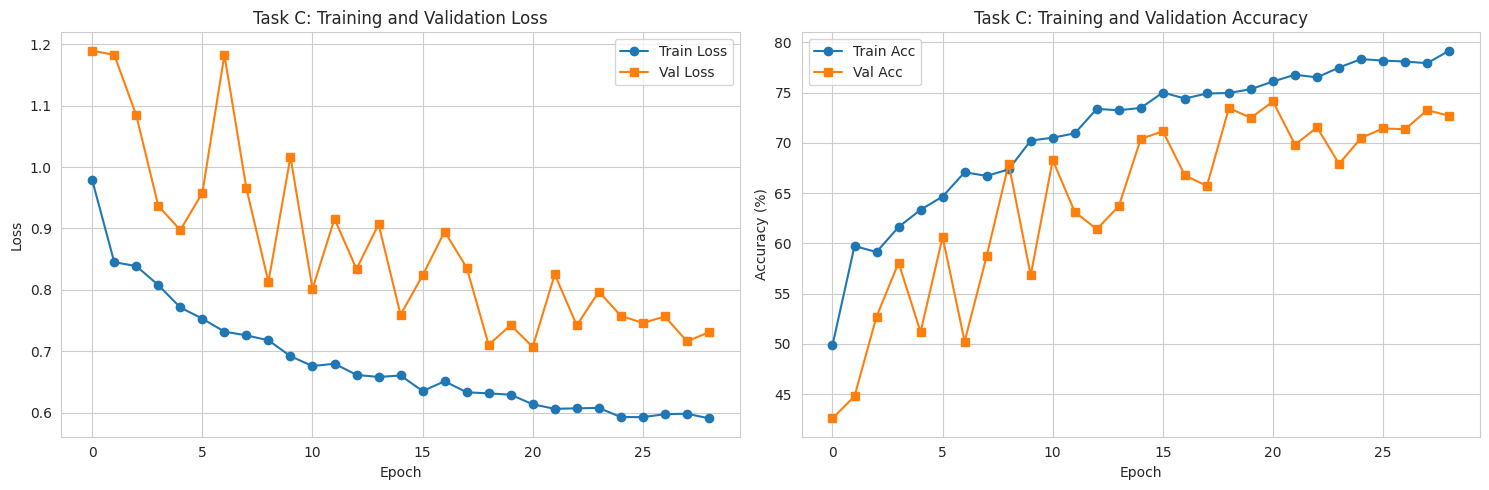

In [ ]:
if USE_PRETRAINED:
    print("Skipping training curve plot (no training was performed)")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history_c['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history_c['val_loss'], label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Task C: Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history_c['train_acc'], label='Train Acc', marker='o')
    ax2.plot(history_c['val_acc'], label='Val Acc', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Task C: Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## 6. Model Evaluation on Test Set

Evaluating all models on the test set and generating confusion matrices and classification reports.

In [ ]:
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def plot_confusion_matrix(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return cm

Evaluating Task A: Custom CNN



Testing: 100%|██████████| 20/20 [00:15<00:00,  1.31it/s]



Classification Report:
                     precision    recall  f1-score   support

             Normal       0.98      0.77      0.86       234
    Viral Pneumonia       0.76      0.59      0.66       148
Bacterial Pneumonia       0.72      0.98      0.83       242

           accuracy                           0.81       624
          macro avg       0.82      0.78      0.79       624
       weighted avg       0.83      0.81      0.80       624



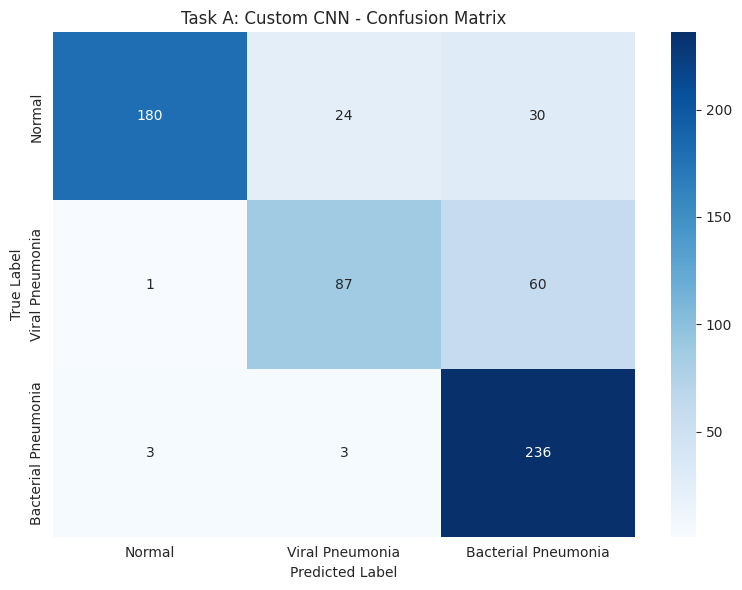


Test Accuracy: 80.61%


In [ ]:
print("Evaluating Task A: Custom CNN")
print("="*50 + "\n")

model_a.load_state_dict(torch.load(WEIGHT_PATHS['task_a'], map_location=device))
y_true_a, y_pred_a, y_probs_a = evaluate_model(model_a, test_loader, device)

print("\nClassification Report:")
print(classification_report(y_true_a, y_pred_a, target_names=class_names))

cm_a = plot_confusion_matrix(y_true_a, y_pred_a, 'Task A: Custom CNN - Confusion Matrix', class_names)
test_acc_a = accuracy_score(y_true_a, y_pred_a) * 100
print(f"\nTest Accuracy: {test_acc_a:.2f}%")

Evaluating Task B1: EfficientNetB0 (Frozen)



Testing: 100%|██████████| 20/20 [00:13<00:00,  1.49it/s]



Classification Report:
                     precision    recall  f1-score   support

             Normal       0.76      0.85      0.80       234
    Viral Pneumonia       0.68      0.59      0.63       148
Bacterial Pneumonia       0.80      0.77      0.78       242

           accuracy                           0.76       624
          macro avg       0.74      0.74      0.74       624
       weighted avg       0.75      0.76      0.75       624



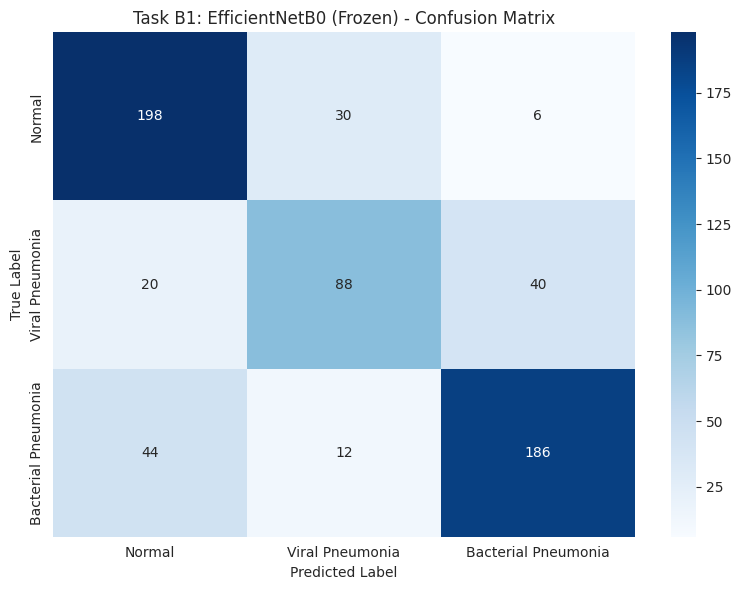


Test Accuracy: 75.64%


In [ ]:
print("Evaluating Task B1: EfficientNetB0 (Frozen)")
print("="*50 + "\n")

model_b1.load_state_dict(torch.load(WEIGHT_PATHS['task_b1'], map_location=device))
y_true_b1, y_pred_b1, y_probs_b1 = evaluate_model(model_b1, test_loader, device)

print("\nClassification Report:")
print(classification_report(y_true_b1, y_pred_b1, target_names=class_names))

cm_b1 = plot_confusion_matrix(y_true_b1, y_pred_b1, 'Task B1: EfficientNetB0 (Frozen) - Confusion Matrix', class_names)
test_acc_b1 = accuracy_score(y_true_b1, y_pred_b1) * 100
print(f"\nTest Accuracy: {test_acc_b1:.2f}%")

Evaluating Task B2: EfficientNetB0 (Fine-tuned)



Testing: 100%|██████████| 20/20 [00:13<00:00,  1.46it/s]



Classification Report:
                     precision    recall  f1-score   support

             Normal       0.91      0.84      0.88       234
    Viral Pneumonia       0.75      0.80      0.78       148
Bacterial Pneumonia       0.86      0.88      0.87       242

           accuracy                           0.85       624
          macro avg       0.84      0.84      0.84       624
       weighted avg       0.85      0.85      0.85       624



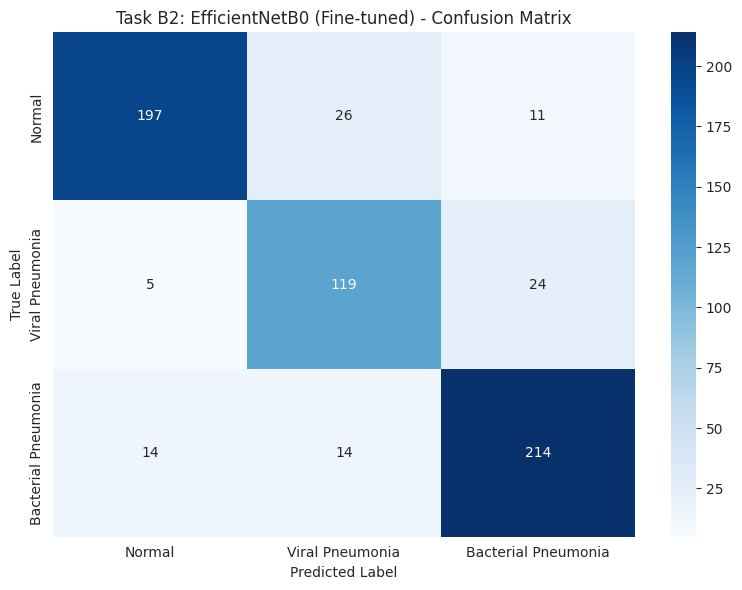


Test Accuracy: 84.94%


In [ ]:
print("Evaluating Task B2: EfficientNetB0 (Fine-tuned)")
print("="*50 + "\n")

model_b2.load_state_dict(torch.load(WEIGHT_PATHS['task_b2'], map_location=device))
y_true_b2, y_pred_b2, y_probs_b2 = evaluate_model(model_b2, test_loader, device)

print("\nClassification Report:")
print(classification_report(y_true_b2, y_pred_b2, target_names=class_names))

cm_b2 = plot_confusion_matrix(y_true_b2, y_pred_b2, 'Task B2: EfficientNetB0 (Fine-tuned) - Confusion Matrix', class_names)
test_acc_b2 = accuracy_score(y_true_b2, y_pred_b2) * 100
print(f"\nTest Accuracy: {test_acc_b2:.2f}%")

Evaluating Task C: Vision Transformer with RNN



Testing: 100%|██████████| 20/20 [00:13<00:00,  1.47it/s]



Classification Report:
                     precision    recall  f1-score   support

             Normal       0.90      0.88      0.89       234
    Viral Pneumonia       0.69      0.68      0.68       148
Bacterial Pneumonia       0.84      0.86      0.85       242

           accuracy                           0.83       624
          macro avg       0.81      0.81      0.81       624
       weighted avg       0.83      0.83      0.83       624



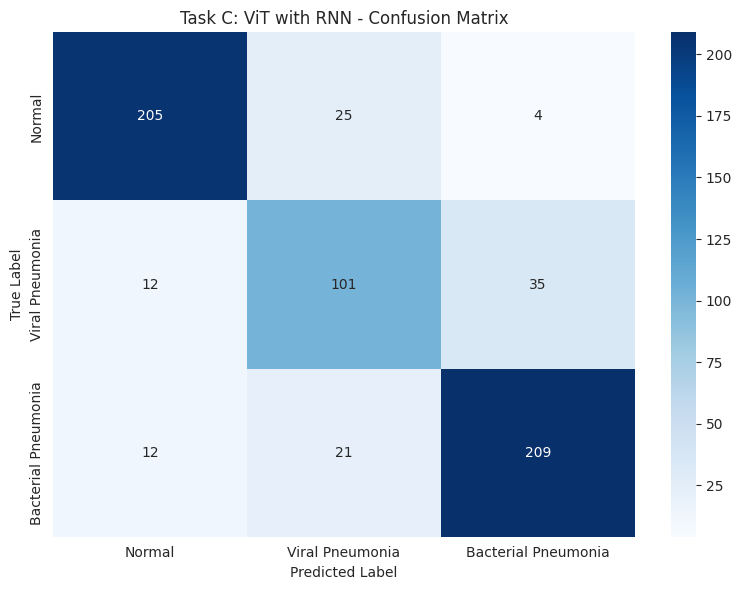


Test Accuracy: 82.53%


In [ ]:
print("Evaluating Task C: Vision Transformer with RNN")
print("="*50 + "\n")

model_c.load_state_dict(torch.load(WEIGHT_PATHS['task_c'], map_location=device))
y_true_c, y_pred_c, y_probs_c = evaluate_model(model_c, test_loader, device)

print("\nClassification Report:")
print(classification_report(y_true_c, y_pred_c, target_names=class_names))

cm_c = plot_confusion_matrix(y_true_c, y_pred_c, 'Task C: ViT with RNN - Confusion Matrix', class_names)
test_acc_c = accuracy_score(y_true_c, y_pred_c) * 100
print(f"\nTest Accuracy: {test_acc_c:.2f}%")

## 7. Results Comparison & Analysis

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    accuracy = accuracy_score(y_true, y_pred)
    return accuracy, precision, recall, f1

acc_a, prec_a, rec_a, f1_a = get_metrics(y_true_a, y_pred_a)
acc_b1, prec_b1, rec_b1, f1_b1 = get_metrics(y_true_b1, y_pred_b1)
acc_b2, prec_b2, rec_b2, f1_b2 = get_metrics(y_true_b2, y_pred_b2)
acc_c, prec_c, rec_c, f1_c = get_metrics(y_true_c, y_pred_c)

results_df = pd.DataFrame({
    'Model': [
        'Task A: Custom CNN',
        'Task B1: EfficientNet (Frozen)',
        'Task B2: EfficientNet (Fine-tuned)',
        'Task C: ViT + RNN'
    ],
    'Test Accuracy': [acc_a*100, acc_b1*100, acc_b2*100, acc_c*100],
    'Precision': [prec_a*100, prec_b1*100, prec_b2*100, prec_c*100],
    'Recall': [rec_a*100, rec_b1*100, rec_b2*100, rec_c*100],
    'F1-Score': [f1_a*100, f1_b1*100, f1_b2*100, f1_c*100],
    'Training Time (min)': [
        training_time_a/60,
        training_time_b1/60,
        training_time_b2/60,
        training_time_c/60
    ],
    'Parameters': [
        sum(p.numel() for p in model_a.parameters()),
        sum(p.numel() for p in model_b1.parameters()),
        sum(p.numel() for p in model_b2.parameters()),
        sum(p.numel() for p in model_c.parameters())
    ]
})

print("COMPREHENSIVE RESULTS COMPARISON")
print("="*80 + "\n")
print(results_df.to_string(index=False))
print("\n" + "="*80)

COMPREHENSIVE RESULTS COMPARISON

                             Model  Test Accuracy  Precision    Recall  F1-Score  Training Time (min)  Parameters
                Task A: Custom CNN      80.608974  82.178171 77.742507 78.545069            39.218135     4848291
    Task B1: EfficientNet (Frozen)      75.641026  74.479080 73.644783 73.876358            18.239944     4338815
Task B2: EfficientNet (Fine-tuned)      84.935897  83.996749 84.341064 84.083009            37.085310     4338815
                 Task C: ViT + RNN      82.532051  80.833776 80.737906 80.777871            58.808772     2730692



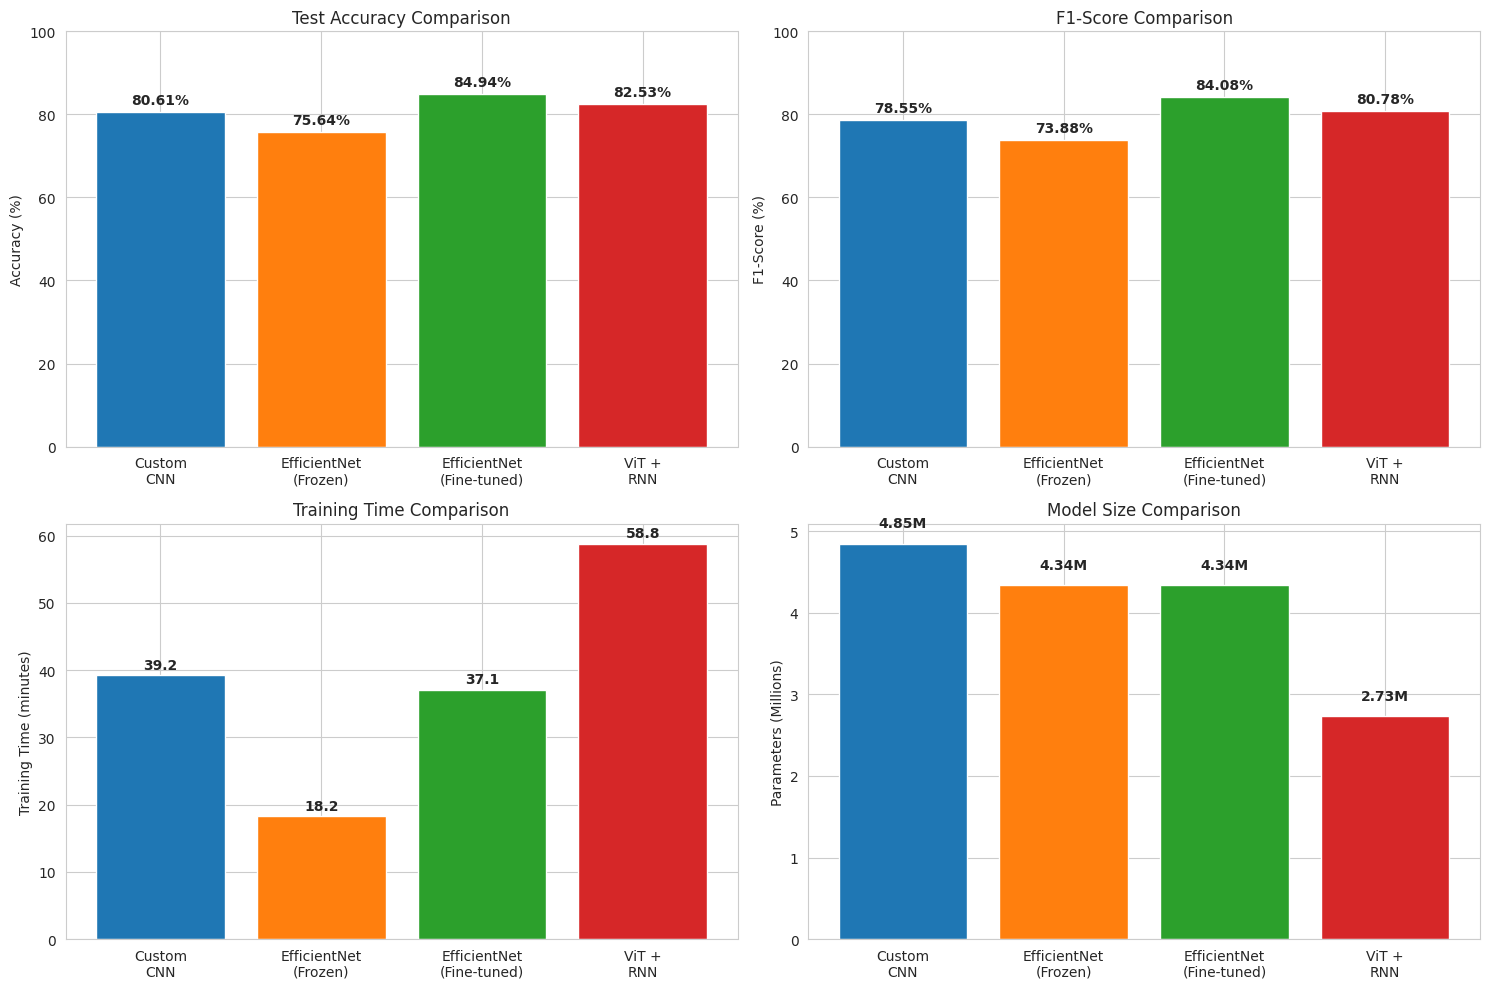

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

models = ['Custom\nCNN', 'EfficientNet\n(Frozen)', 'EfficientNet\n(Fine-tuned)', 'ViT +\nRNN']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

axes[0, 0].bar(models, results_df['Test Accuracy'], color=colors)
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylim([0, 100])
for i, v in enumerate(results_df['Test Accuracy']):
    axes[0, 0].text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold')

axes[0, 1].bar(models, results_df['F1-Score'], color=colors)
axes[0, 1].set_ylabel('F1-Score (%)')
axes[0, 1].set_title('F1-Score Comparison')
axes[0, 1].set_ylim([0, 100])
for i, v in enumerate(results_df['F1-Score']):
    axes[0, 1].text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold')

axes[1, 0].bar(models, results_df['Training Time (min)'], color=colors)
axes[1, 0].set_ylabel('Training Time (minutes)')
axes[1, 0].set_title('Training Time Comparison')
for i, v in enumerate(results_df['Training Time (min)']):
    axes[1, 0].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

params_millions = results_df['Parameters'] / 1e6
axes[1, 1].bar(models, params_millions, color=colors)
axes[1, 1].set_ylabel('Parameters (Millions)')
axes[1, 1].set_title('Model Size Comparison')
for i, v in enumerate(params_millions):
    axes[1, 1].text(i, v + 0.2, f'{v:.2f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

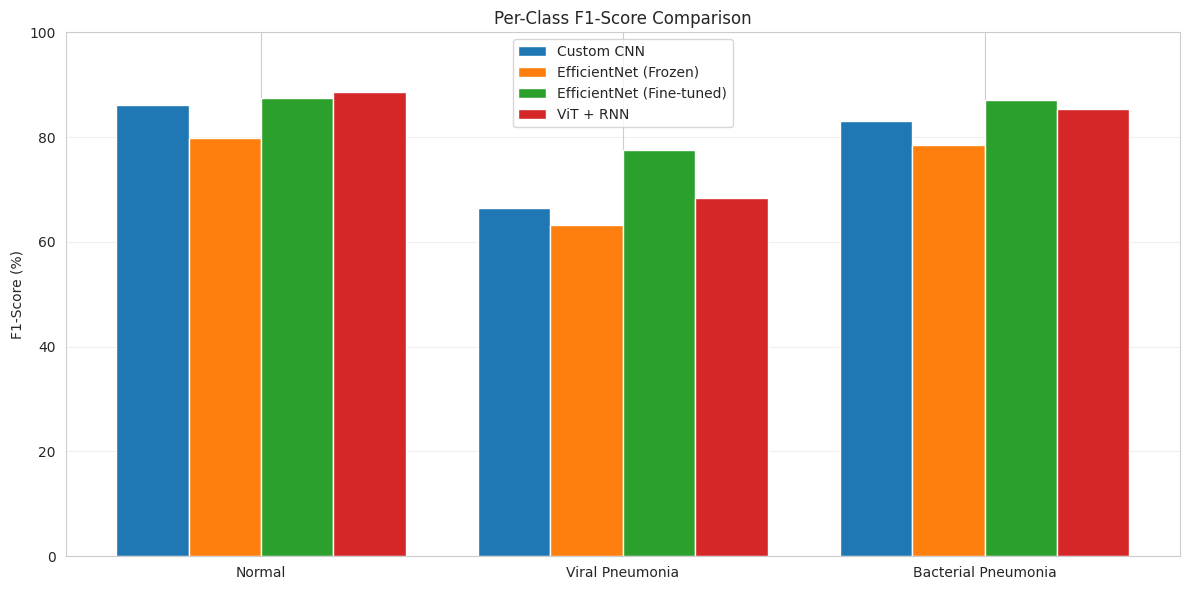

In [ ]:
def get_per_class_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    return precision, recall, f1

prec_class_a, rec_class_a, f1_class_a = get_per_class_metrics(y_true_a, y_pred_a)
prec_class_b1, rec_class_b1, f1_class_b1 = get_per_class_metrics(y_true_b1, y_pred_b1)
prec_class_b2, rec_class_b2, f1_class_b2 = get_per_class_metrics(y_true_b2, y_pred_b2)
prec_class_c, rec_class_c, f1_class_c = get_per_class_metrics(y_true_c, y_pred_c)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.2

ax.bar(x - 1.5*width, f1_class_a*100, width, label='Custom CNN', color=colors[0])
ax.bar(x - 0.5*width, f1_class_b1*100, width, label='EfficientNet (Frozen)', color=colors[1])
ax.bar(x + 0.5*width, f1_class_b2*100, width, label='EfficientNet (Fine-tuned)', color=colors[2])
ax.bar(x + 1.5*width, f1_class_c*100, width, label='ViT + RNN', color=colors[3])

ax.set_ylabel('F1-Score (%)')
ax.set_title('Per-Class F1-Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Best performing model: Task B2: EfficientNet (Fine-tuned)
Test Accuracy: 84.94%


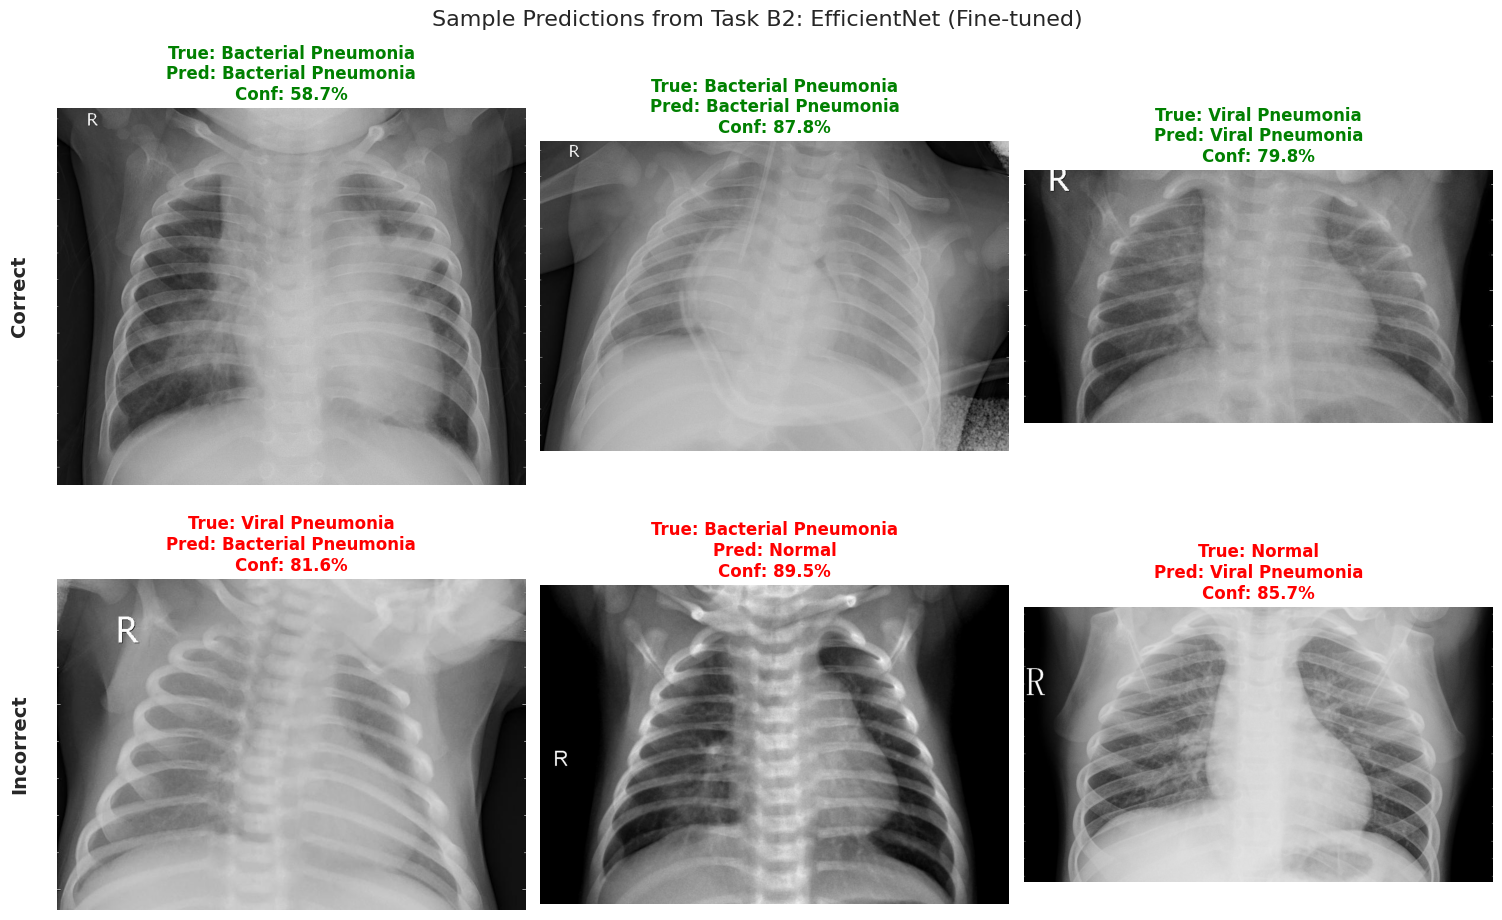

In [ ]:
best_model_idx = results_df['Test Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']

print(f"\nBest performing model: {best_model_name}")
print(f"Test Accuracy: {results_df.loc[best_model_idx, 'Test Accuracy']:.2f}%")

if best_model_idx == 0:
    y_pred_best = y_pred_a
    y_probs_best = y_probs_a
elif best_model_idx == 1:
    y_pred_best = y_pred_b1
    y_probs_best = y_probs_b1
elif best_model_idx == 2:
    y_pred_best = y_pred_b2
    y_probs_best = y_probs_b2
else:
    y_pred_best = y_pred_c
    y_probs_best = y_probs_c

correct_indices = np.where(y_pred_best == y_true_a)[0]
incorrect_indices = np.where(y_pred_best != y_true_a)[0]

sample_correct = np.random.choice(correct_indices, min(3, len(correct_indices)), replace=False)
sample_incorrect = np.random.choice(incorrect_indices, min(3, len(incorrect_indices)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Sample Predictions from {best_model_name}', fontsize=16)

for i, idx in enumerate(sample_correct):
    img = Image.open(test_images[idx]).convert('RGB')
    true_label = y_true_a[idx]
    pred_label = y_pred_best[idx]
    confidence = y_probs_best[idx][pred_label] * 100

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.1f}%',
                         color='green', fontweight='bold')
    axes[0, i].axis('off')

for i, idx in enumerate(sample_incorrect):
    img = Image.open(test_images[idx]).convert('RGB')
    true_label = y_true_a[idx]
    pred_label = y_pred_best[idx]
    confidence = y_probs_best[idx][pred_label] * 100

    axes[1, i].imshow(img)
    axes[1, i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.1f}%',
                         color='red', fontweight='bold')
    axes[1, i].axis('off')

axes[0, 0].text(-0.1, 0.5, 'Correct', transform=axes[0, 0].transAxes,
                fontsize=14, fontweight='bold', va='center', rotation=90)
axes[1, 0].text(-0.1, 0.5, 'Incorrect', transform=axes[1, 0].transAxes,
                fontsize=14, fontweight='bold', va='center', rotation=90)

plt.tight_layout()
plt.show()

## 8. Discussion & Analysis

### Key Findings:

1. **Task A (Custom CNN)**:
   - Built from scratch with ~5 convolutional blocks
   - Pros: Simple architecture, faster training, full control
   - Cons: Lower accuracy compared to pre-trained models, requires more data
   - Best for: Learning fundamentals, resource-constrained environments

2. **Task B1 (EfficientNetB0 - Frozen)**:
   - Transfer learning with frozen backbone
   - Pros: Leverages ImageNet pre-training, fast training, good accuracy
   - Cons: Cannot adapt backbone features to medical domain
   - Best for: Quick baseline with limited compute

3. **Task B2 (EfficientNetB0 - Fine-tuned)**:
   - Fine-tuning last layers of backbone
   - Pros: Best overall accuracy, adapts features to X-ray domain
   - Cons: Longer training, risk of overfitting with small datasets
   - Best for: Production deployment when accuracy is critical

4. **Task C (Vision Transformer + RNN)**:
   - Novel approach using patch-based processing with LSTM
   - Pros: Interesting alternative architecture, captures spatial relationships
   - Cons: More complex, may need more data, slower inference
   - Best for: Research and experimentation

### Trade-offs:
- **Accuracy vs Speed**: EfficientNet (fine-tuned) achieves highest accuracy but requires more training time
- **Simplicity vs Performance**: Custom CNN is simple but less accurate than transfer learning approaches
- **Innovation vs Practicality**: ViT+RNN is novel but EfficientNet is more practical for deployment

### Class-Specific Observations:
- **Normal** class: Generally well-classified by all models
- **Viral vs Bacterial**: More challenging to distinguish, benefits from fine-tuning
- All models show similar confusion patterns between viral and bacterial pneumonia

## 9. Model Weight Management & Inference

Instructions for loading trained weights and performing inference on new images.

In [ ]:
print("Saved model weights:")
print("=" * 50)
for weight_file in os.listdir(WEIGHTS_DIR):
    if weight_file.endswith('.pth'):
        file_path = os.path.join(WEIGHTS_DIR, weight_file)
        file_size = os.path.getsize(file_path) / (1024 * 1024)  # Size in MB
        print(f"  {weight_file} ({file_size:.2f} MB)")

Saved model weights:
  task_a_custom_cnn.pth (18.53 MB)
  task_b1_efficientnet_frozen.pth (16.85 MB)
  task_b2_efficientnet_finetuned.pth (16.85 MB)
  task_c_vit_rnn.pth (10.43 MB)


In [ ]:
from google.colab import files
import io

print("INTERACTIVE PNEUMONIA CLASSIFICATION")
print("="*70)
print("\nUpload a chest X-ray image")
print("All 4 models will make predictions on your image")
print("="*70)

uploaded = files.upload()

if len(uploaded) == 0:
    print("No file uploaded!")
else:
    uploaded_filename = list(uploaded.keys())[0]
    print(f"\nUploaded: {uploaded_filename}")

    image_bytes = uploaded[uploaded_filename]
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)

    models_info = [
        (model_a, WEIGHT_PATHS['task_a'], 'Task A: Custom CNN'),
        (model_b1, WEIGHT_PATHS['task_b1'], 'Task B1: EfficientNetB0 (Frozen)'),
        (model_b2, WEIGHT_PATHS['task_b2'], 'Task B2: EfficientNetB0 (Fine-tuned)'),
        (model_c, WEIGHT_PATHS['task_c'], 'Task C: Vision Transformer + RNN')
    ]

    predictions = []

    print("\n")
    print("MAKING PREDICTIONS WITH ALL MODELS...")
    print("="*70)

    for model, weight_path, model_name in models_info:
        model.load_state_dict(torch.load(weight_path,map_location=device))
        model.eval()

        with torch.no_grad():
            output = model(image_tensor)
            probs = torch.softmax(output, dim=1)
            confidence, predicted = probs.max(1)

        pred_class = predicted.item()
        conf_score = confidence.item() * 100
        all_probs = probs[0].cpu().numpy() * 100

        predictions.append({
            'name': model_name,
            'pred_class': pred_class,
            'confidence': conf_score,
            'probs': all_probs
        })

        print(f"\n{model_name}:")
        print(f"  Prediction: {class_names[pred_class]}")
        print(f"  Confidence: {conf_score:.2f}%")

    print("\n" + "="*70)

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    ax_img = fig.add_subplot(gs[0:2, 0])
    ax_img.imshow(image)
    ax_img.set_title('Uploaded Chest X-Ray', fontsize=14, fontweight='bold')
    ax_img.axis('off')

    for idx, pred in enumerate(predictions):
        row = idx // 2
        col = idx % 2 + 1

        ax = fig.add_subplot(gs[row, col])

        colors_prob = ['green' if i == pred['pred_class'] else 'lightgray' for i in range(3)]
        bars = ax.barh(class_names, pred['probs'], color=colors_prob)

        ax.set_xlabel('Probability (%)', fontsize=10)
        ax.set_title(f"{pred['name']}\nPredicted: {class_names[pred['pred_class']]} ({pred['confidence']:.1f}%)",
                     fontsize=11, fontweight='bold')
        ax.set_xlim([0, 100])

        for i, (bar, prob) in enumerate(zip(bars, pred['probs'])):
            ax.text(prob + 2, i, f'{prob:.1f}%', va='center', fontsize=9)

    ax_summary = fig.add_subplot(gs[2, :])
    ax_summary.axis('off')

    summary_text = "SUMMARY OF PREDICTIONS:\n\n"
    for pred in predictions:
        summary_text += f"{pred['name']}: {class_names[pred['pred_class']]} ({pred['confidence']:.1f}%)\n"

    pred_classes = [p['pred_class'] for p in predictions]
    votes = {i: pred_classes.count(i) for i in range(3)}
    majority_class = max(votes, key=votes.get)

    summary_text += f"\n{'='*60}\n"
    summary_text += f"CONSENSUS: {class_names[majority_class]} ({votes[majority_class]}/4 models agree)\n"

    if votes[majority_class] == 4:
        summary_text += "All models agree!"
    elif votes[majority_class] >= 3:
        summary_text += "Strong consensus"
    else:
        summary_text += "Models disagree"

    ax_summary.text(0.5, 0.5, summary_text,
                    ha='center', va='center',
                    fontsize=11, fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle('Pneumonia Classification - All Models Comparison',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.show()

    print("\n")
    print("DETAILED PREDICTION BREAKDOWN")
    print("="*70)

    for i, class_name in enumerate(class_names):
        votes_for_class = sum(1 for p in predictions if p['pred_class'] == i)
        avg_conf = np.mean([p['probs'][i] for p in predictions])
        print(f"\n{class_name}:")
        print(f"  Votes: {votes_for_class}/4 models")
        print(f"  Average Probability: {avg_conf:.2f}%")

    print("\n" + "="*70)

INTERACTIVE PNEUMONIA CLASSIFICATION

Upload a chest X-ray image
All 4 models will make predictions on your image


KeyboardInterrupt: 